# Python Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report, confusion_matrix

# Import data


In [2]:
col_types = {
    "cough": float,
    "fever": float,
    "sore_throat": float,
    "shortness_of_breath": float,
    "head_ache": float,
    "corona_result": str,
    "age_60_and_above": str,
    "gender": str,
    "test_indication": str,
}
df = pd.read_csv(
    "data/corona_tested_individuals_ver_006.english.csv",
    dtype=col_types,
    parse_dates=["test_date"],
)

In [3]:
df

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other
...,...,...,...,...,...,...,...,...,...,...
278843,2020-03-11,0.0,0.0,0.0,0.0,0.0,negative,NaN,NaN,Other
278844,2020-03-11,0.0,0.0,0.0,0.0,0.0,negative,NaN,NaN,Other
278845,2020-03-11,0.0,0.0,0.0,0.0,0.0,positive,NaN,NaN,Contact with confirmed
278846,2020-03-11,0.0,0.0,0.0,0.0,0.0,other,NaN,NaN,Other


# Analyse Data


In [4]:
df.describe()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache
count,278848,278596.000000,278596.000000,278847.000000,278847.000000,278847.000000
mean,2020-04-10 11:50:32.361716480,0.151574,0.078077,0.006907,0.005655,0.008657
min,2020-03-11 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020-04-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2020-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2020-04-21 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
max,2020-04-30 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,0.358608,0.268294,0.082821,0.074990,0.092640


In [5]:
df.describe(include="O")

,corona_result,age_60_and_above,gender,test_indication
count,278848,151528,259285,278848
unique,3,2,2,3
top,negative,No,female,Other
freq,260227,125703,130158,242741


In [6]:
for col in df.columns:
    print(df[col].value_counts(dropna=False, normalize=True), "\n")

test_date
2020-04-20    0.039165
2020-04-19    0.036575
2020-04-22    0.034592
2020-04-21    0.034513
2020-04-16    0.032771
2020-04-23    0.031358
2020-04-01    0.031035
2020-04-13    0.030214
2020-04-02    0.029364
2020-04-03    0.028973
2020-04-17    0.027416
2020-04-05    0.026929
2020-04-30    0.026226
2020-04-27    0.026193
2020-04-15    0.025638
2020-03-31    0.025584
2020-04-24    0.025204
2020-03-26    0.023895
2020-04-14    0.023565
2020-04-28    0.022715
2020-04-18    0.022668
2020-04-26    0.021987
2020-04-12    0.021460
2020-03-27    0.021384
2020-04-07    0.021270
2020-03-30    0.021212
2020-04-10    0.020362
2020-03-28    0.020090
2020-03-25    0.019706
2020-04-06    0.019251
2020-03-29    0.018924
2020-04-04    0.018451
2020-04-25    0.018117
2020-03-24    0.016981
2020-04-09    0.016278
2020-04-11    0.015568
2020-04-29    0.015274
2020-04-08    0.014553
2020-03-22    0.012785
2020-03-23    0.012530
2020-03-19    0.008044
2020-03-18    0.007140
2020-03-20    0.006706
2

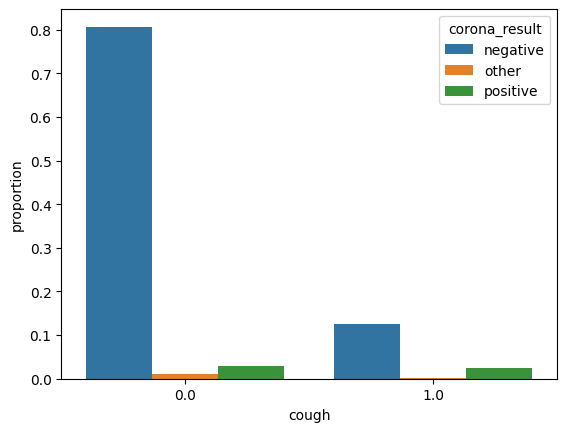

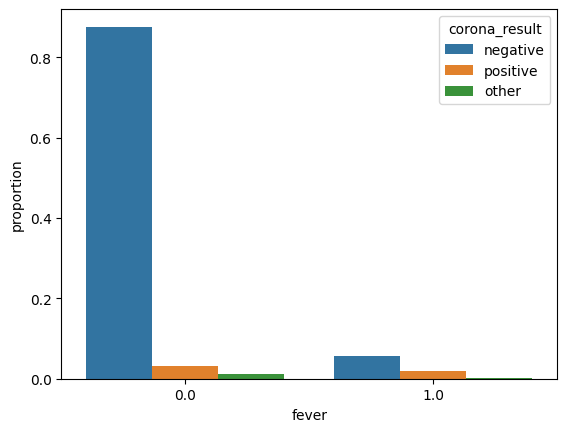

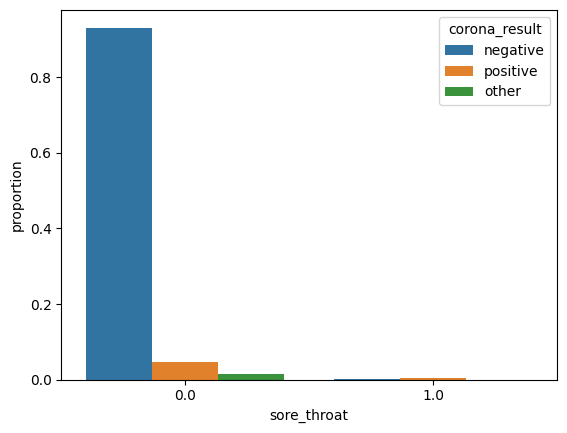

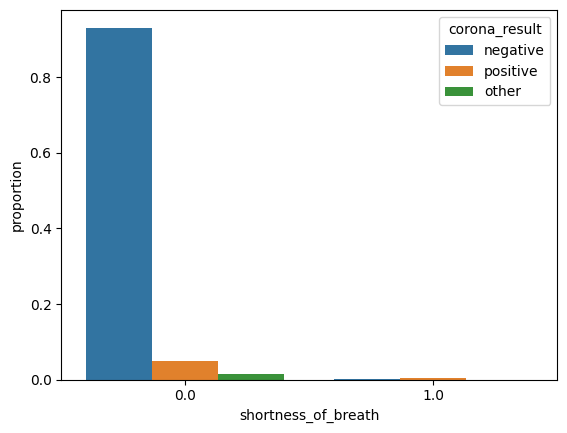

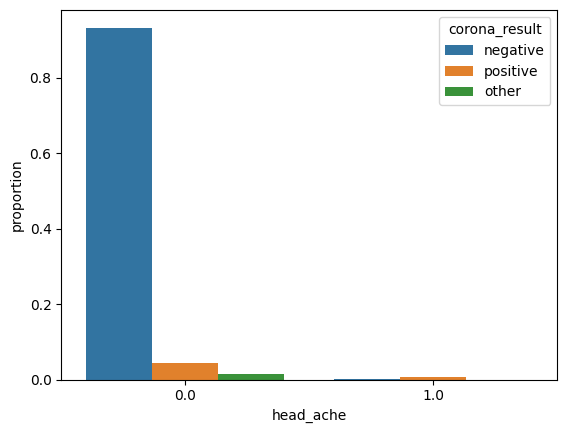

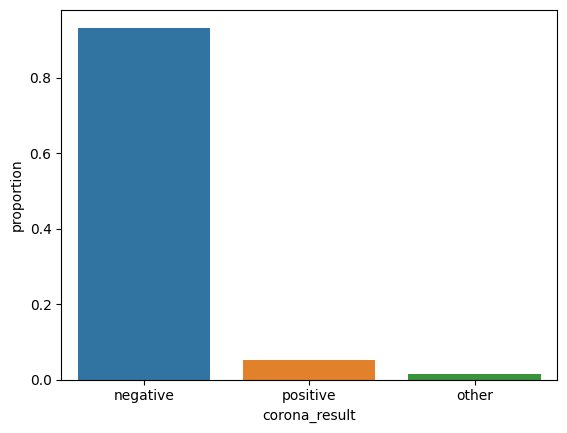

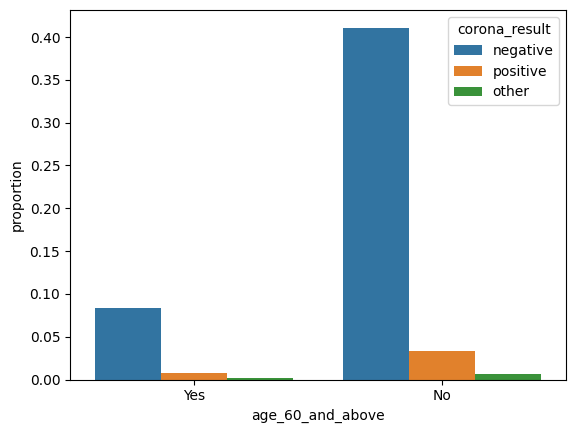

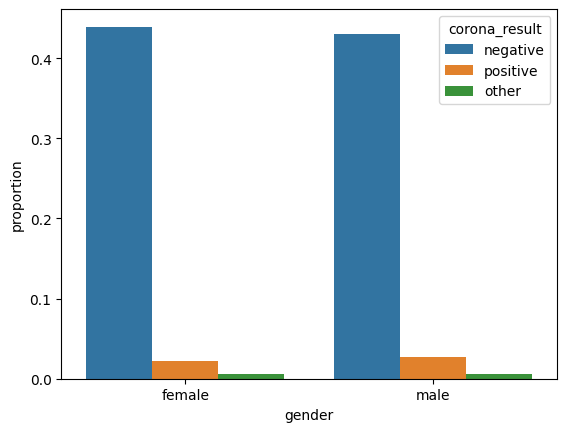

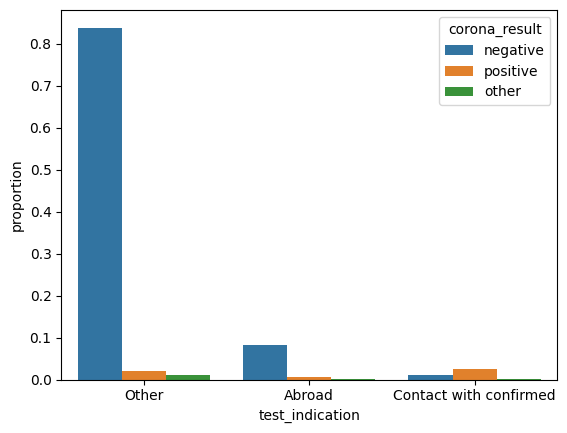

In [7]:
for col in df.columns[1:]:
    sns.countplot(data=df, x=col, hue="corona_result", stat="proportion")
    plt.show()

# Clean Data


In [8]:
# Drop date column since it is not relevant for modeling
df = df.drop(columns=["test_date"])

# Drop rows with missing target variable
df = df[df["corona_result"] != "other"]

# Set target variable to boolean
df["corona_result"] = df["corona_result"].map({"positive": True, "negative": False})

In [9]:
# Set data types

df["cough"] = df["cough"].astype("category")
df["fever"] = df["fever"].astype("category")
df["sore_throat"] = df["sore_throat"].astype("category")
df["shortness_of_breath"] = df["shortness_of_breath"].astype("category")
df["head_ache"] = df["head_ache"].astype("category")
df["corona_result"] = df["corona_result"].astype("bool")
df["age_60_and_above"] = df["age_60_and_above"].astype("category")
df["gender"] = df["gender"].astype("category")
df["test_indication"] = df["test_indication"].astype("category")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274956 entries, 0 to 278847
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   cough                274704 non-null  category
 1   fever                274704 non-null  category
 2   sore_throat          274955 non-null  category
 3   shortness_of_breath  274955 non-null  category
 4   head_ache            274955 non-null  category
 5   corona_result        274956 non-null  bool    
 6   age_60_and_above     149292 non-null  category
 7   gender               255911 non-null  category
 8   test_indication      274956 non-null  category
dtypes: bool(1), category(8)
memory usage: 4.5 MB


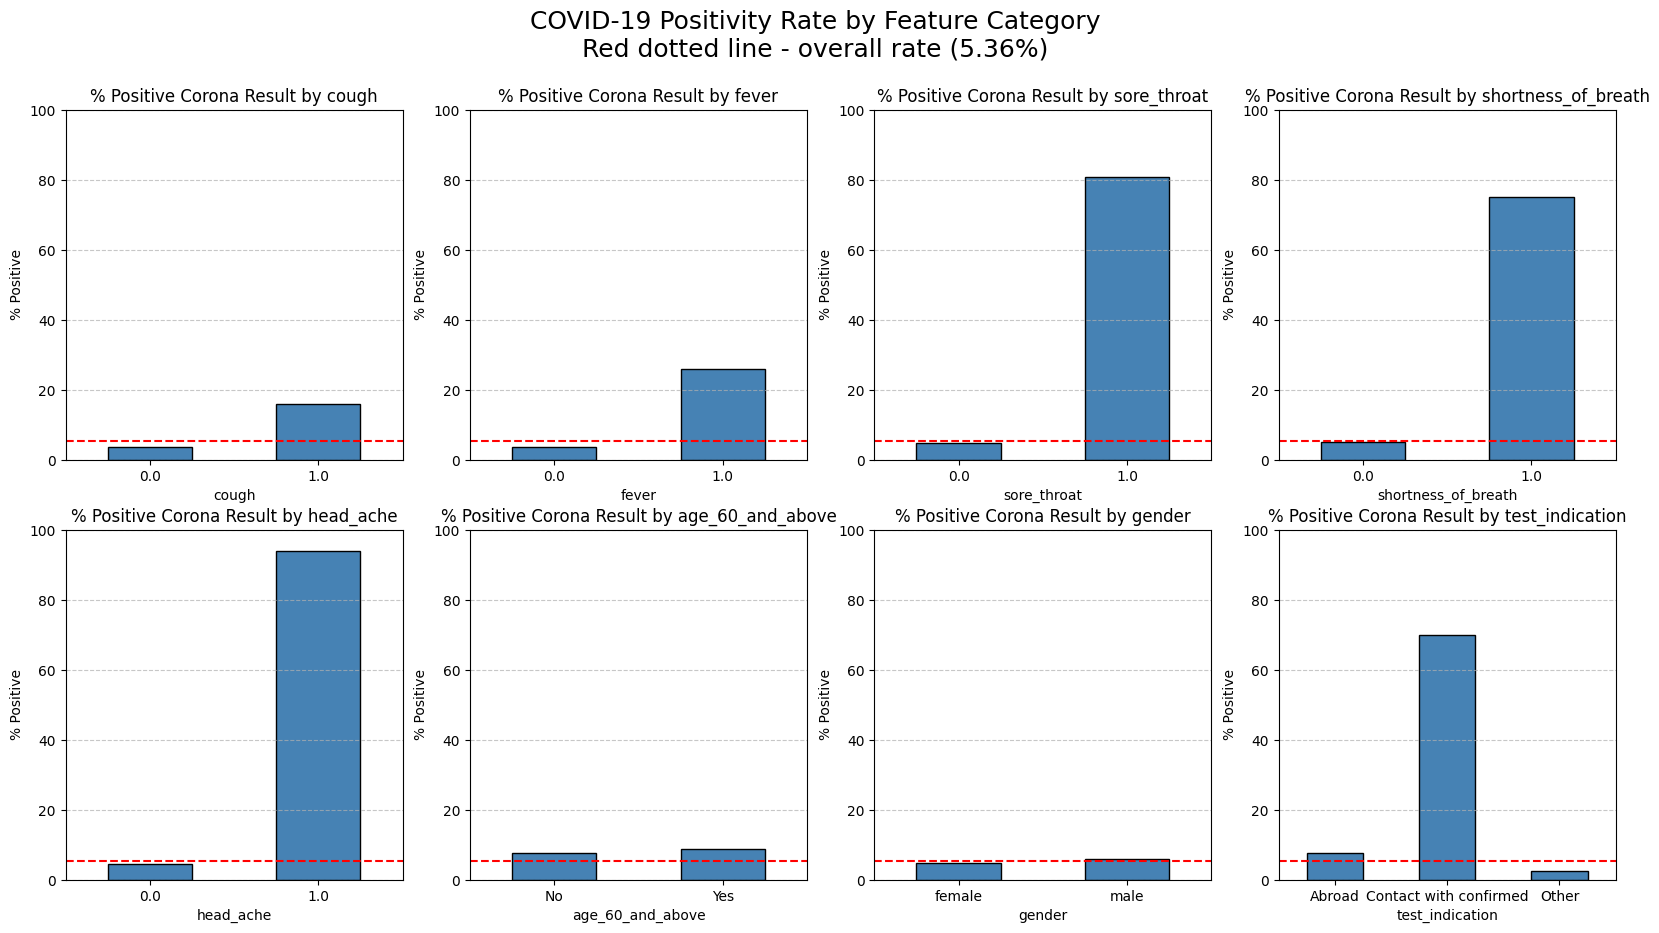

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

feature_cols = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache",
    "age_60_and_above",
    "gender",
    "test_indication",
]

pos_rate = df["corona_result"].mean() * 100

for i, col in enumerate(feature_cols):
    covid_rate = df.groupby(col, observed=True)["corona_result"].mean() * 100
    covid_rate.plot(kind="bar", ax=axes[i], color="steelblue", edgecolor="black")
    axes[i].axhline(pos_rate, color="red", linestyle="--", label="Overall Rate")
    axes[i].set_title(f"% Positive Corona Result by {col}")
    axes[i].set_ylabel("% Positive")
    axes[i].set_xlabel(col)
    axes[i].set_ylim(0, 100)
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)
    axes[i].tick_params(axis="x", rotation=0)

plt.suptitle(f"COVID-19 Positivity Rate by Feature Category\nRed dotted line - overall rate ({pos_rate:.2f}%)", fontsize=18)
plt.show()

# Train Test Split


In [12]:
X = df.drop("corona_result", axis=1)
y = df["corona_result"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

In [13]:
y.value_counts(normalize=True)

corona_result
False    0.946431
True     0.053569
Name: proportion, dtype: float64

In [14]:
y_train.value_counts(normalize=True)

corona_result
False    0.94643
True     0.05357
Name: proportion, dtype: float64

In [15]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

# Setting Parameters


In [16]:
params = {
    "boosting_type": "gbdt",
    "objective": "binary",
    "metric": "auc",
    "is_unbalance": True,
}

# Train Model


[LightGBM] [Info] Number of positive: 11047, number of negative: 195170
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25
[LightGBM] [Info] Number of data points in the train set: 206217, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.053570 -> initscore=-2.871712
[LightGBM] [Info] Start training from score -2.871712
Training until validation scores don't improve for 50 rounds
[10]	train's auc: 0.905899	test's auc: 0.91296
[20]	train's auc: 0.906567	test's auc: 0.914461
[30]	train's auc: 0.906943	test's auc: 0.914551
[40]	train's auc: 0.907419	test's auc: 0.915139
[50]	train's auc: 0.907769	test's auc: 0.915069
[60]	train's auc: 0.907889	test's auc: 0.91514
[70]	train's auc: 0.907919	test's auc: 0.91505
[80]	train's auc: 0.908095	test's auc: 0.914983
[

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

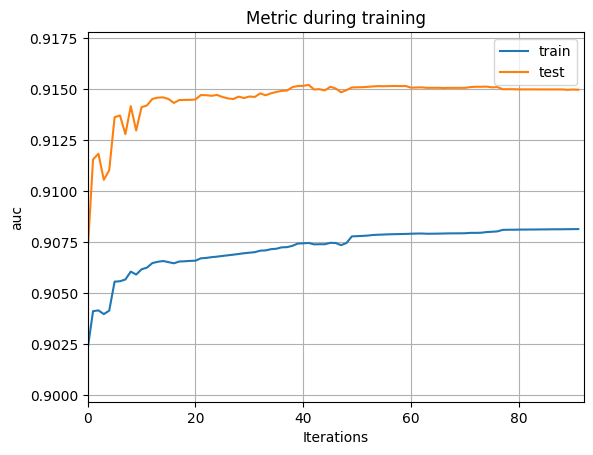

In [17]:
evals = {}

model = lgb.train(
    params=params,
    train_set=lgb_train,
    valid_sets=[lgb_train, lgb_test],
    valid_names=["train", "test"],
    callbacks=[lgb.record_evaluation(evals), lgb.log_evaluation(10), lgb.early_stopping(stopping_rounds=50)],
    num_boost_round=1000
)

lgb.plot_metric(evals)

# Feature Importance


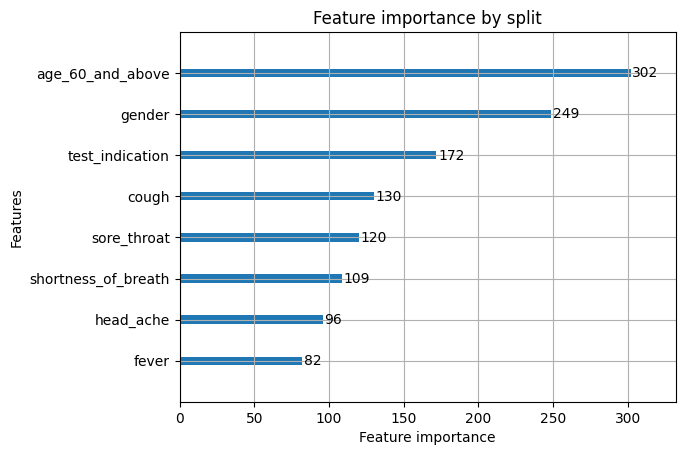

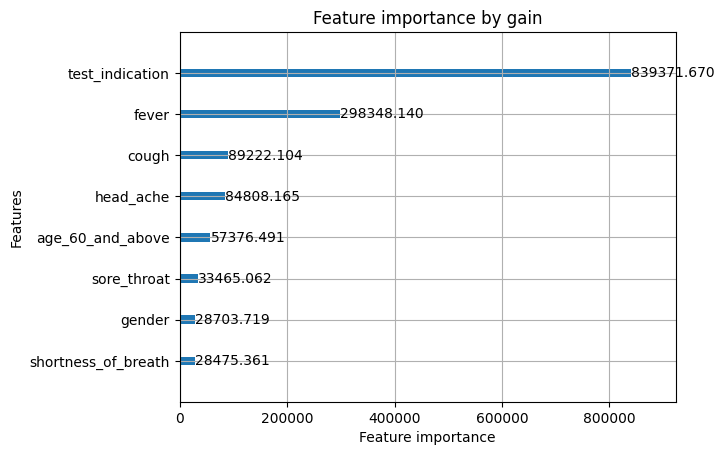

In [18]:
for imp_type in ["split", "gain"]:
    ax = lgb.plot_importance(
        model,
        importance_type=imp_type,
        dpi=100,
        title=f"Feature importance by {imp_type}",
    )

# Metrics


In [19]:
y_probs = model.predict(X_test)

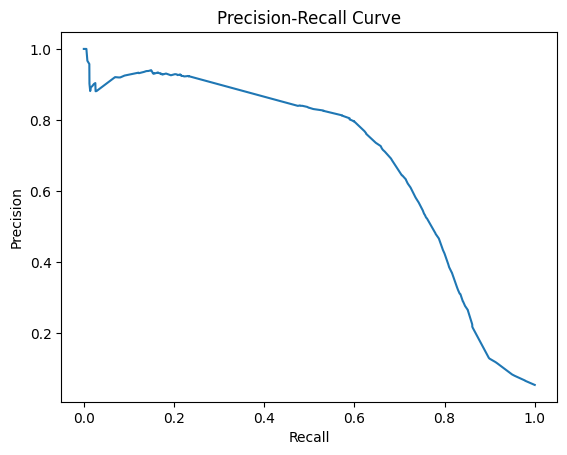

In [20]:
fig_prc, ax_prc = plt.subplots()
precision, recall, thresholds_prc = precision_recall_curve(y_test, y_probs)
ax_prc.plot(recall, precision)
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.set_title("Precision-Recall Curve")
plt.show()

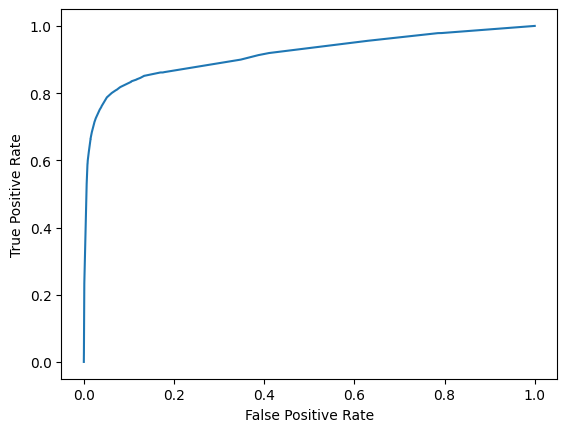

In [21]:
fig_roc, ax_roc = plt.subplots()
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
fnr = 1 - tpr
tnr = 1 - fpr
ax_roc.plot(fpr, tpr)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
plt.show()

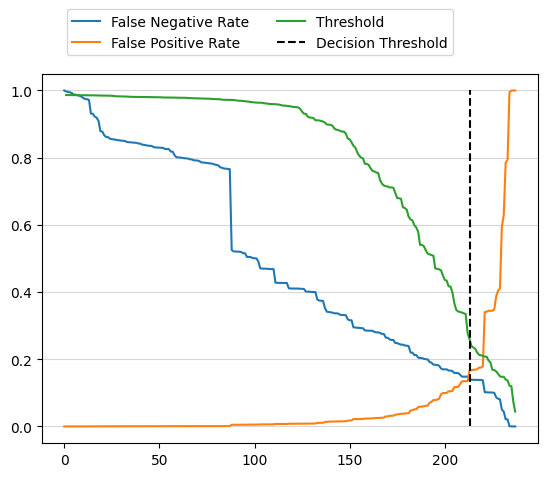

In [22]:
plt.plot(fnr, label="False Negative Rate")
plt.plot(fpr, label="False Positive Rate")
# plt.plot(tpr, label="True Positive Rate")
# plt.plot(tnr, label="True Negative Rate")
plt.plot(thresholds, label="Threshold")
index_roc = np.where(fnr < fpr)[0][0]
plt.plot(
    [index_roc, index_roc],
    [0, 1],
    color="k",
    linestyle="--",
    label="Decision Threshold",
)
plt.legend(loc=[0.05, 1.05], ncol=2)
plt.grid(axis="y", alpha=0.5)
plt.show()

In [23]:
threshold = thresholds[index_roc]
print(f"Threshold: {threshold:.4f}")
print(f"False Negative Rate at threshold: {fnr[index_roc]:.4f}")
print(f"False Positive Rate at threshold: {fpr[index_roc]:.4f}")

Threshold: 0.2599
False Negative Rate at threshold: 0.1391
False Positive Rate at threshold: 0.1670


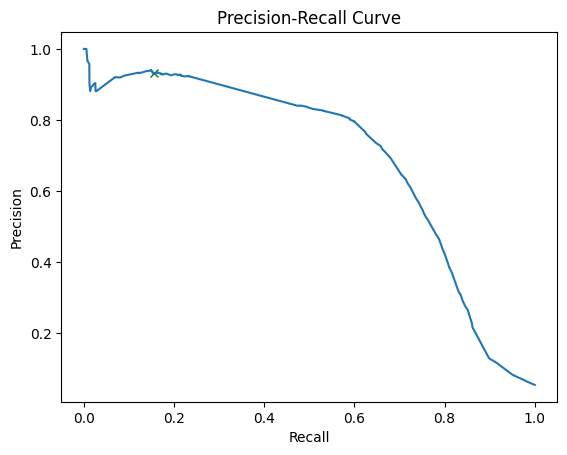

In [24]:
fig_prc, ax_prc = plt.subplots()
precision, recall, thresholds_prc = precision_recall_curve(y_test, y_probs)
plt.plot(recall[index_roc], precision[index_roc], "gx")
ax_prc.plot(recall, precision)
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.set_title("Precision-Recall Curve")
plt.show()

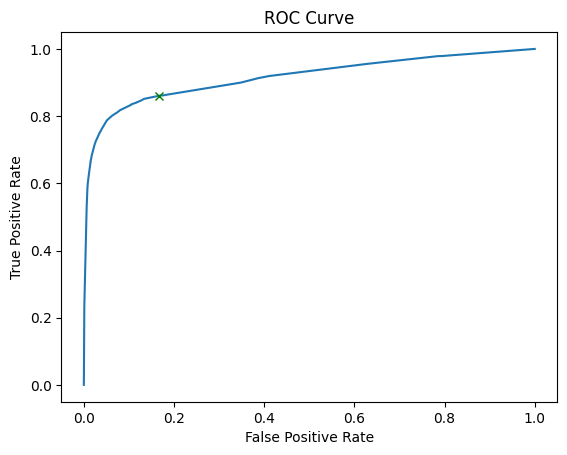

In [25]:
plt.plot(fpr, tpr)
plt.plot(fpr[index_roc], tpr[index_roc], "gx")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

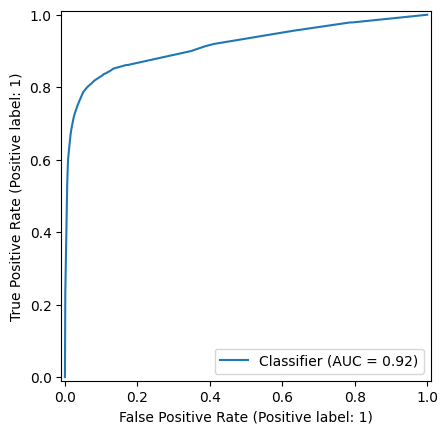

In [26]:
RocCurveDisplay.from_predictions(y_test, y_probs)

In [27]:
auc = roc_auc_score(y_test, y_probs)
print(f"AUC: {auc:.4f}")

AUC: 0.9152


In [28]:
def predict_class(model, data, threshold=0.5):

    y_pred = model.predict(data)

    return np.where(y_pred > threshold, 1, 0)

In [29]:
y_pred = predict_class(model, X_test, threshold=threshold)

# Summary

   CLASSIFICATION SUMMARY
True Positive Rate:	85.17%
True Negative Rate:	86.51%
False Positive Rate:	13.49%
False Negative Rate:	14.83%
------------------------------
ROC-AUC Score:        0.9152
PR-AUC Score:         0.6799
------------------------------
Classification Report:

              precision    recall  f1-score   support

       False       0.99      0.87      0.92     65057
        True       0.26      0.85      0.40      3682

    accuracy                           0.86     68739
   macro avg       0.63      0.86      0.66     68739
weighted avg       0.95      0.86      0.90     68739



Text(0.5, 1.0, 'Threshold at ROC-Optimal Point')

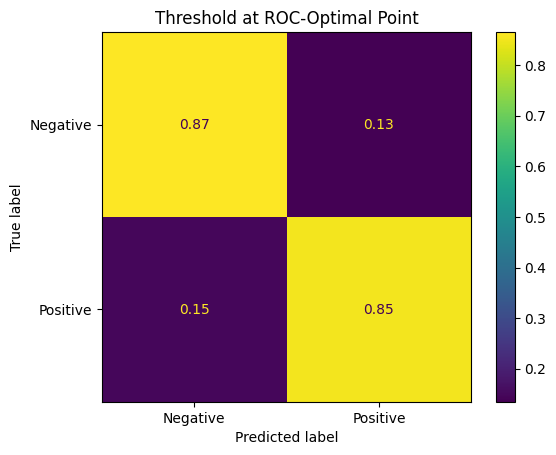

In [30]:
# 1. Calculate raw counts
# .ravel() flattens the 2x2 matrix into individual variables
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# 2. Calculate Rates
total_pos = tp + fn  # All actual positive cases
total_neg = tn + fp  # All actual negative cases

tpr = tp / total_pos  # True Positive Rate (Recall / Sensitivity)
fnr = fn / total_pos  # False Negative Rate (Miss Rate) - YOUR TARGET
tnr = tn / total_neg  # True Negative Rate (Specificity)
fpr = fp / total_neg  # False Positive Rate (Fall-out)

# 2. Calculate ROC-AUC (using probabilities, not predictions)
auc_val = roc_auc_score(y_test, y_probs)

pr_auc = average_precision_score(y_test, y_probs)

print("="*30)
print("   CLASSIFICATION SUMMARY")
print("="*30)
print(f"True Positive Rate:\t{tpr:.2%}")
print(f"True Negative Rate:\t{tnr:.2%}")
print(f"False Positive Rate:\t{fpr:.2%}")
print(f"False Negative Rate:\t{fnr:.2%}")
print("-"*30)
print(f"ROC-AUC Score:        {auc_val:.4f}")
print(f"PR-AUC Score:         {pr_auc:.4f}")

print("-"*30)

# 3. Detailed Report (Precision, Recall, F1)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"), display_labels=["Negative", "Positive"]).plot()
plt.title("Threshold at ROC-Optimal Point")

In [31]:
y_pred_half = predict_class(model, X_test, threshold=0.5)

   CLASSIFICATION SUMMARY
True Positive Rate:	81.59%
True Negative Rate:	92.15%
False Positive Rate:	7.85%
False Negative Rate:	18.41%
------------------------------
ROC-AUC Score:        0.9152
PR-AUC Score:         0.6799
------------------------------
Classification Report:

              precision    recall  f1-score   support

       False       0.99      0.92      0.95     65057
        True       0.37      0.82      0.51      3682

    accuracy                           0.92     68739
   macro avg       0.68      0.87      0.73     68739
weighted avg       0.96      0.92      0.93     68739



Text(0.5, 1.0, 'Threshold at 0.5')

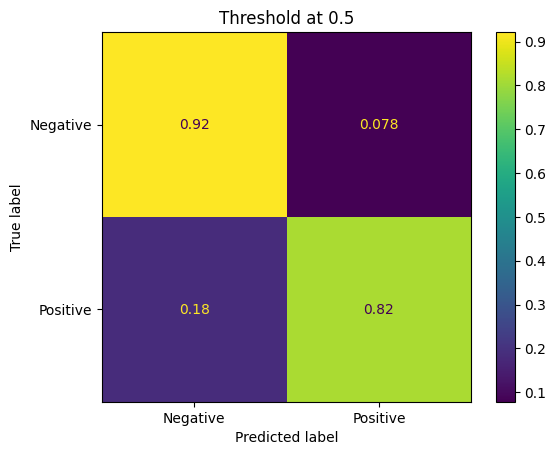

In [32]:
# 1. Calculate raw counts
# .ravel() flattens the 2x2 matrix into individual variables
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_half).ravel()

# 2. Calculate Rates
total_pos = tp + fn  # All actual positive cases
total_neg = tn + fp  # All actual negative cases

tpr = tp / total_pos  # True Positive Rate (Recall / Sensitivity)
fnr = fn / total_pos  # False Negative Rate (Miss Rate) - YOUR TARGET
tnr = tn / total_neg  # True Negative Rate (Specificity)
fpr = fp / total_neg  # False Positive Rate (Fall-out)

# 2. Calculate ROC-AUC (using probabilities, not predictions)
auc_val = roc_auc_score(y_test, y_probs)

pr_auc = average_precision_score(y_test, y_probs)

print("="*30)
print("   CLASSIFICATION SUMMARY")
print("="*30)
print(f"True Positive Rate:\t{tpr:.2%}")
print(f"True Negative Rate:\t{tnr:.2%}")
print(f"False Positive Rate:\t{fpr:.2%}")
print(f"False Negative Rate:\t{fnr:.2%}")
print("-"*30)
print(f"ROC-AUC Score:        {auc_val:.4f}")
print(f"PR-AUC Score:         {pr_auc:.4f}")
print("-"*30)

# 3. Detailed Report (Precision, Recall, F1)
print("Classification Report:\n")
print(classification_report(y_test, y_pred_half))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_half, normalize="true"), display_labels=["Negative", "Positive"]).plot()
plt.title("Threshold at 0.5")